**Cell 1: GPU Check & Mount Google Drive**

In [2]:
import torch
from google.colab import drive

# Mount Google Drive to save your outputs and best model weights
drive.mount('/content/drive')

# Verify GPU is available
print("GPU Available:", torch.cuda.is_available())
!nvidia-smi

Mounted at /content/drive
GPU Available: True
Wed Aug 19 17:35:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-

**Cell 2: Install Required Packages**

In [3]:
!pip install -U ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.4 MB/s eta 0:00:00


**Cell 3: Download Annotated Dataset from Roboflow**

In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="cOYwJOfiyGQuZmBJ6bCT")
project = rf.workspace("azka-tahir").project("violation-atfhu-agqyn")
version = project.version(1)
dataset = version.download("yolov8")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/violation-1


**Cell 4: Train YOLOv8 Model**

In [6]:
from ultralytics import YOLO

# Load lightweight pretrained YOLOv8 model
model = YOLO('yolov8n.pt')

# Train for 30 epochs
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    pretrained=True,
    project='/content/drive/MyDrive/cv_project/outputs/training_results',
    name='yolov8n_violation'
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.123 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/violation-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, f

**Cell 5: Run Inference on Test Images**

In [9]:
from ultralytics import YOLO

# 1. Load your newly trained model weights
model = YOLO('/content/drive/MyDrive/cv_project/outputs/training_results/yolov8n_violation/weights/best.pt')

# 2. Run inference with exist_ok=True
results = model.predict(
    source=f"{dataset.location}/test/images",  # Points dynamically to your newly downloaded violation dataset
    conf=0.35,
    save=True,
    project='/content/drive/MyDrive/cv_project/outputs/predictions',
    name='violation_test_predictions',          # Giving it a fresh, unique folder name
    exist_ok=True                                # Overwrites if folder already exists
)


image 1/29 /content/violation-1/test/images/camera1_48b02d6010d9_2025_04_14_17_39_30_jpg.rf.f9c26eaa6dd1ca789f840fa2f4a94ac2.jpg: 640x640 1 no_seatbelt, 1 seatbelt, 1 vehicle, 24.7ms
image 2/29 /content/violation-1/test/images/camera1_48b02d6010d9_2025_04_14_17_43_22_jpg.rf.060c52229c080e112874d87fe6968fd1.jpg: 640x640 1 no_seatbelt, 2 seatbelts, 1 vehicle, 46.0ms
image 3/29 /content/violation-1/test/images/camera1_48b02d6010d9_2025_04_14_17_45_41_jpg.rf.82313eafa6c94ab6f39d4e11e43eee39.jpg: 640x640 1 no_seatbelt, 1 vehicle, 24.7ms
image 4/29 /content/violation-1/test/images/camera1_48b02d6010d9_2025_04_14_17_49_16_jpg.rf.220e10f70f153a30b382669d2b29036f.jpg: 640x640 1 no_seatbelt, 1 vehicle, 13.6ms
image 5/29 /content/violation-1/test/images/camera1_48b02d6010d9_2025_04_14_17_53_05_jpg.rf.a52d80a29a91d5a7125787f4530c7af2.jpg: 640x640 1 no_seatbelt, 1 vehicle, 20.4ms
image 6/29 /content/violation-1/test/images/camera1_48b02d6010d9_2025_04_14_18_01_22_jpg.rf.fb3ac509e3918011142ac1d4d36

**Cell 6: Display Predictions Directly in Colab**

Found 29 predicted images.
Displaying: /content/drive/MyDrive/cv_project/outputs/predictions/violation_test_predictions/camera1_48b02d6010d9_2025_04_14_17_39_30_jpg.rf.f9c26eaa6dd1ca789f840fa2f4a94ac2.jpg


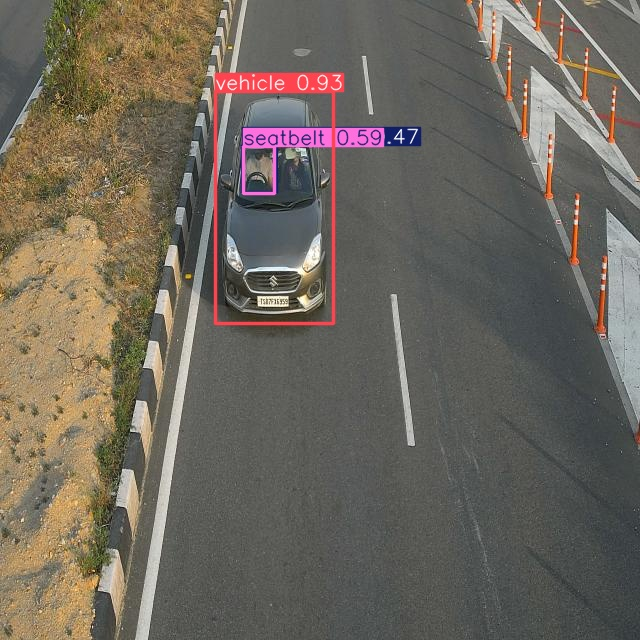

--------------------------------------------------
Displaying: /content/drive/MyDrive/cv_project/outputs/predictions/violation_test_predictions/camera1_48b02d6010d9_2025_04_14_17_43_22_jpg.rf.060c52229c080e112874d87fe6968fd1.jpg


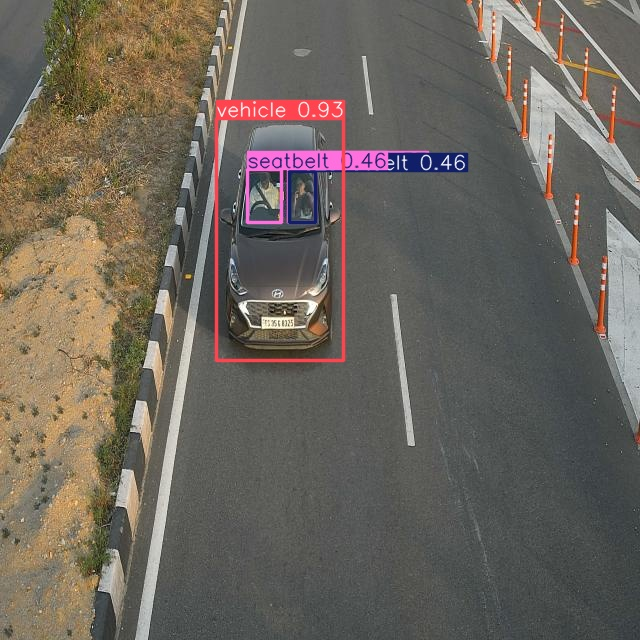

--------------------------------------------------
Displaying: /content/drive/MyDrive/cv_project/outputs/predictions/violation_test_predictions/camera1_48b02d6010d9_2025_04_14_17_45_41_jpg.rf.82313eafa6c94ab6f39d4e11e43eee39.jpg


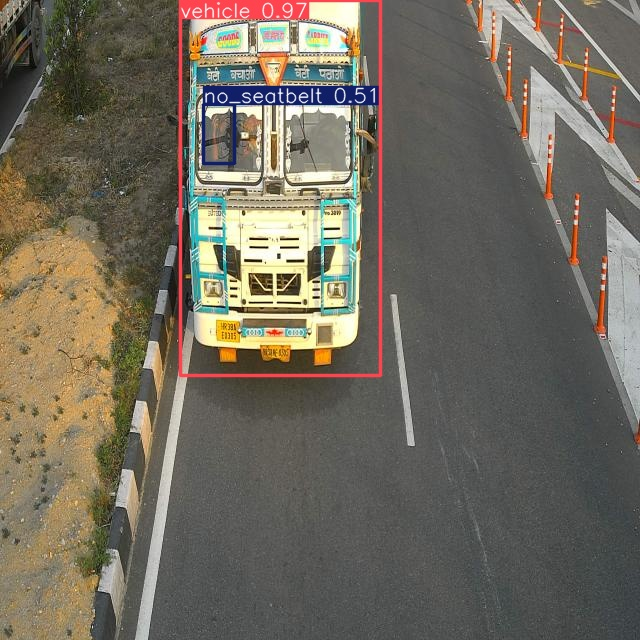

--------------------------------------------------
Displaying: /content/drive/MyDrive/cv_project/outputs/predictions/violation_test_predictions/camera1_48b02d6010d9_2025_04_14_17_49_16_jpg.rf.220e10f70f153a30b382669d2b29036f.jpg


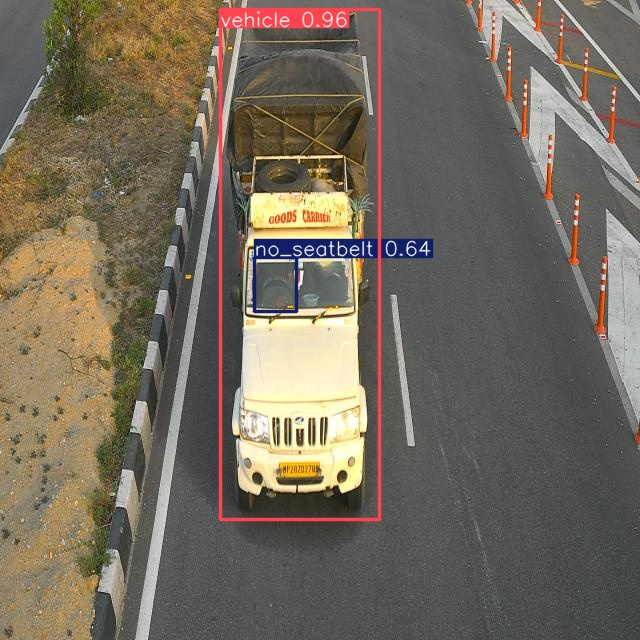

--------------------------------------------------
Displaying: /content/drive/MyDrive/cv_project/outputs/predictions/violation_test_predictions/camera1_48b02d6010d9_2025_04_14_17_53_05_jpg.rf.a52d80a29a91d5a7125787f4530c7af2.jpg


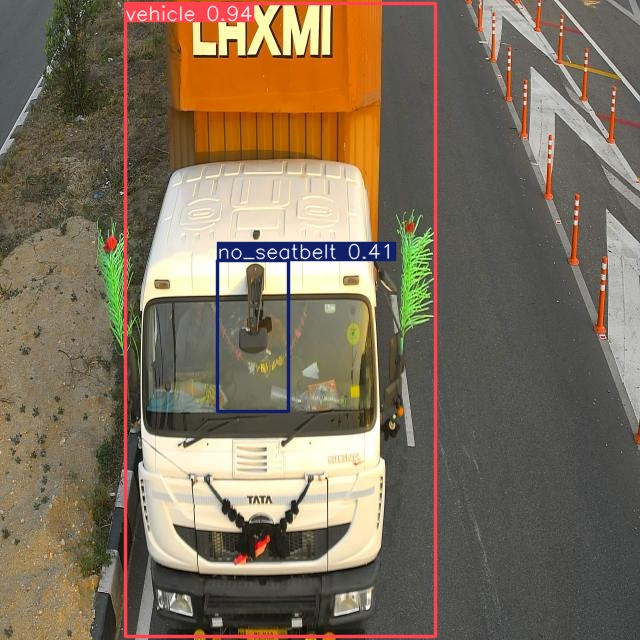

--------------------------------------------------


In [10]:
import glob
from IPython.display import Image, display

# Grab output images from the new predictions directory
prediction_images = glob.glob('/content/drive/MyDrive/cv_project/outputs/predictions/violation_test_predictions/*.jpg')

print(f"Found {len(prediction_images)} predicted images.")

# Display the first 5 predictions
for img_path in prediction_images[:5]:
    print("Displaying:", img_path)
    display(Image(filename=img_path))
    print("-" * 50)